# **1. Product Health Overview**

This block answers one business question: **is the subscription business growing or declining, and what is driving the change?**

The selected metrics cover the full subscription growth chain:

1. **Top-of-funnel demand**
   - registrations
   - trial starts

2. **Conversion quality**
   - registration-to-paid conversion: 15-day and 30-day windows

3. **Paid base movement**
   - new subscriptions
   - ended subscriptions
   - net subscription growth rate
   - subscription churn rate

4. **Business outcome**
   - active subscriptions
   - revenue

This structure helps identify the main possible drivers of change:

- fewer or more users entering the product
- weaker or stronger conversion into paid subscriptions
- higher or lower subscription churn
- a mix of these factors

--------------

**Metric definitions:**

- **Monthly registrations** = users registered in each month
- **Monthly trial users** = users who started a trial in each month
- **Registration-to-paid conversion** = users who started a paid subscription within X days after registration / users registered in the cohort
- **Monthly new subscriptions** = subscriptions started in each month
- **Monthly ended subscriptions** = subscriptions ended in each month
- **Net subscription growth** = active subscriptions this month - active subscriptions in the previous month
- **Net subscription growth rate** = net subscription growth / active subscriptions at the end of the previous month
- **Monthly subscription churn rate** = subscriptions ended in each month / active subscriptions at the end of the previous month ¹
- **Monthly active subscriptions** = subscriptions active at the end of each month
- **Monthly revenue** = sum of successful payment amounts within each month

*¹ a stricter churn formula would have **active subscriptions at the beginning of the same month as a denominator**. In this analysis, the end of the previous month active base is used as a proxy*

##**1.0 Data, libraries and functions import**

In [ ]:
# -----------------
# loading libraries
# -----------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# -----------------
# loading functions
# -----------------

from preprocessing import bulk_convert_to_datetime

from visualizing import line_chart_formatting

from conversions import (
    bulk_maturity_flags,
    cr_calculation
)

In [ ]:
# ---------------
# loading sources
# ---------------

users = pd.read_csv('users_adjusted.csv')
trials = pd.read_csv('trials_adjusted.csv')
subscriptions = pd.read_csv('subscriptions_adjusted.csv')
payments = pd.read_csv('payments_adjusted.csv')


## **1.1. Processing columns**
### **1.1.0. Column conversion to work with them further**

In [ ]:
# ------------------------------------------------------------------------------
# applying pd.to_datetime to date columns
# ------------------------------------------------------------------------------
columns = [(users, 'registration_date'),
           (users, 'registration_month'),
           (users, 'registration_week'),

           (trials, 'trial_start_date'),
           (trials, 'trial_end_date'),
           (trials, 'trial_start_month'),

           (payments, 'payment_start_date'),
           (payments, 'payment_month'),
           (payments, 'billing_period_start'),
           (payments, 'billing_period_end'),

           (subscriptions, 'subscription_start_date'),
           (subscriptions, 'subscription_end_date'),
           (subscriptions, 'subscription_month'),
           (subscriptions, 'subscription_end_month'),

           (subscriptions, 'plan_change_date'),
           (subscriptions, 'cancellation_date'),
           (subscriptions, 'cancellation_month')]

bulk_convert_to_datetime (columns)

## **1.2. Metric calculation**
Calculating all main metrics:
  - monthly registrations
  - monthly trials
  - monthly active subscriptions & net growth, net growth rate
  - monthly subscriptions churn
  - monthly gross revenue
  - monthly registration-to-paid CR of 15 & 30 day ¹
  
 *¹ Weekly CR calculations were also done to compare granularity. Monthly CR is used for the main analysis because it shows the trend more clearly*

In [ ]:
# ------------------------------------------------------------------------------
# monthly statistics:
# - monthly registrations
# - monthly trials
#
# - monthly active subscriptions & net growth, net growth rate
# - monthly subscriptions churn
#
# - monthly gross revenue
# ------------------------------------------------------------------------------


max_limit = subscriptions['subscription_end_date'].max().to_period('M').to_timestamp(how = 'end')

# monthly registrations
new_registrations = users.groupby('registration_month', as_index = False)['user_id'].nunique().rename(columns = {'user_id' : 'new_users'})

# monthly new subscriptions
monthly_new_subscriptions = subscriptions.groupby('subscription_month', as_index = False)['subscription_id'].nunique().rename(columns = {'subscription_id' : 'new_subscriptions'})

# monthly trials
monthly_trials = trials.groupby('trial_start_month', as_index = False)['user_id'].nunique().rename(columns = {'user_id' : 'trial_users'})

# monthly active subscriptions & net growth, net growth rate
subscriptions_temp = subscriptions.copy()
subscriptions_temp['subscription_end_date'] = subscriptions_temp['subscription_end_date'].fillna(max_limit)


subscriptions_temp['active_months'] = (subscriptions_temp
                                      .apply(lambda r: pd.date_range(r['subscription_start_date'], r['subscription_end_date'], freq = 'ME')
                                      .tolist(),axis=1))

monthly_active_subscriptions = (subscriptions_temp.explode('active_months')
                                                  .groupby('active_months', as_index = False)['subscription_id'].nunique()
                                                  .rename(columns={'active_months': 'Dates', 'subscription_id': 'active_subscriptions'}))

monthly_active_subscriptions['net_subscriptions_growth'] = monthly_active_subscriptions['active_subscriptions'].diff(periods = 1).fillna(0).astype('int')
monthly_active_subscriptions['net_growth_rate'] = (round(monthly_active_subscriptions['net_subscriptions_growth']
                                                          / monthly_active_subscriptions['active_subscriptions'].shift(1) * 100, 1))

# monthly subscriptions churn
ended_subscriptions = (subscriptions[~subscriptions['subscription_end_month'].isna()]
                                    .groupby('subscription_end_month', as_index = False)[['subscription_id', 'user_id']].nunique()
                                    .rename(columns = {'subscription_id' : 'ended_subscriptions'}))

# joining tables
subscription_stats = (monthly_active_subscriptions
                            .merge(ended_subscriptions,
                                  left_on = monthly_active_subscriptions['Dates'].dt.to_period('M').dt.to_timestamp(),
                                  right_on = 'subscription_end_month',
                                  how = 'left'))

subscription_stats = subscription_stats.drop(columns = 'subscription_end_month')
subscription_stats['ended_subscriptions'] = subscription_stats['ended_subscriptions'].fillna(0).astype('int')

subscription_stats['subscription_churn_rate'] = (round(subscription_stats['ended_subscriptions']
                                                          / subscription_stats['active_subscriptions'].shift(1) * 100, 1))

# monthly gross revenue
monthly_payments = payments[payments['payment_status'] == 'succeeded'].groupby('payment_month', as_index = False)['amount_paid'].sum()
monthly_payments['amount_paid'] = round(monthly_payments['amount_paid'] / 1000, 2)


In [ ]:
# ------------------------------------------------------------------------------
# CR registration to subscriber: monthly & weekly
# - 15 day CR
# - 30 day CR
# ------------------------------------------------------------------------------

# first user subscription date & CRs
first_subscription_by_user = (subscriptions.groupby('user_id', as_index = False)
                                                    ['subscription_start_date'].min()
                                                   .rename(columns = {'subscription_start_date' : 'first_subscription_start_date'}))
converted_users = users.merge(first_subscription_by_user, on = 'user_id', how = 'left')

conversions_table_monthly = converted_users.groupby('registration_month', as_index = False)['user_id'].nunique().rename(columns = {'user_id' : 'all_users'})
conversions_table_weekly = converted_users.groupby('registration_week', as_index = False)['user_id'].nunique().rename(columns = {'user_id' : 'all_users'})

# for marking cohort maturity for different windows
tables = [(converted_users, 'registration_date', 'first_subscription_start_date', 15),
          (converted_users, 'registration_date', 'first_subscription_start_date', 30)]

bulk_maturity_flags (tables)

# calculating CRs registraion to paid monthly and weekly
conversions_table_monthly = (conversions_table_monthly.merge(cr_calculation(converted_users,
                                                                          ['registration_month'],
                                                                          'flag_window_15_days_reg_to_fir_maturity',
                                                                          'flag_window_15_days_reg_to_fir_conversion',
                                                                          'CR_15_day',
                                                                           rounded_number = 2),
                                                          on = 'registration_month', how = 'left'))

conversions_table_monthly = (conversions_table_monthly.merge(cr_calculation(converted_users,
                                                                          ['registration_month'],
                                                                          'flag_window_30_days_reg_to_fir_maturity',
                                                                          'flag_window_30_days_reg_to_fir_conversion',
                                                                          'CR_30_day',
                                                                           rounded_number = 2),
                                                          on = 'registration_month', how = 'left'))

conversions_table_weekly = (conversions_table_weekly.merge(cr_calculation(converted_users,
                                                                       ['registration_week'],
                                                                       'flag_window_15_days_reg_to_fir_maturity',
                                                                       'flag_window_15_days_reg_to_fir_conversion',
                                                                       'CR_15_day',
                                                                        rounded_number = 2),
                                                        on = 'registration_week', how = 'left'))

conversions_table_weekly = (conversions_table_weekly.merge(cr_calculation(converted_users,
                                                                        ['registration_week'],
                                                                        'flag_window_30_days_reg_to_fir_maturity',
                                                                        'flag_window_30_days_reg_to_fir_conversion',
                                                                        'CR_30_day',
                                                                         rounded_number = 2),
                                                          on = 'registration_week', how = 'left'))

# dropping immature cohort period to leave on the the periods where all users had a chance to convert
conversions_table_monthly = conversions_table_monthly[conversions_table_monthly['all_users'] == conversions_table_monthly['flag_window_30_days_reg_to_fir_maturity']]
conversions_table_weekly = conversions_table_weekly[conversions_table_weekly['all_users'] == conversions_table_weekly['flag_window_30_days_reg_to_fir_maturity']]

## **1.3. Visualization of the main metrics**

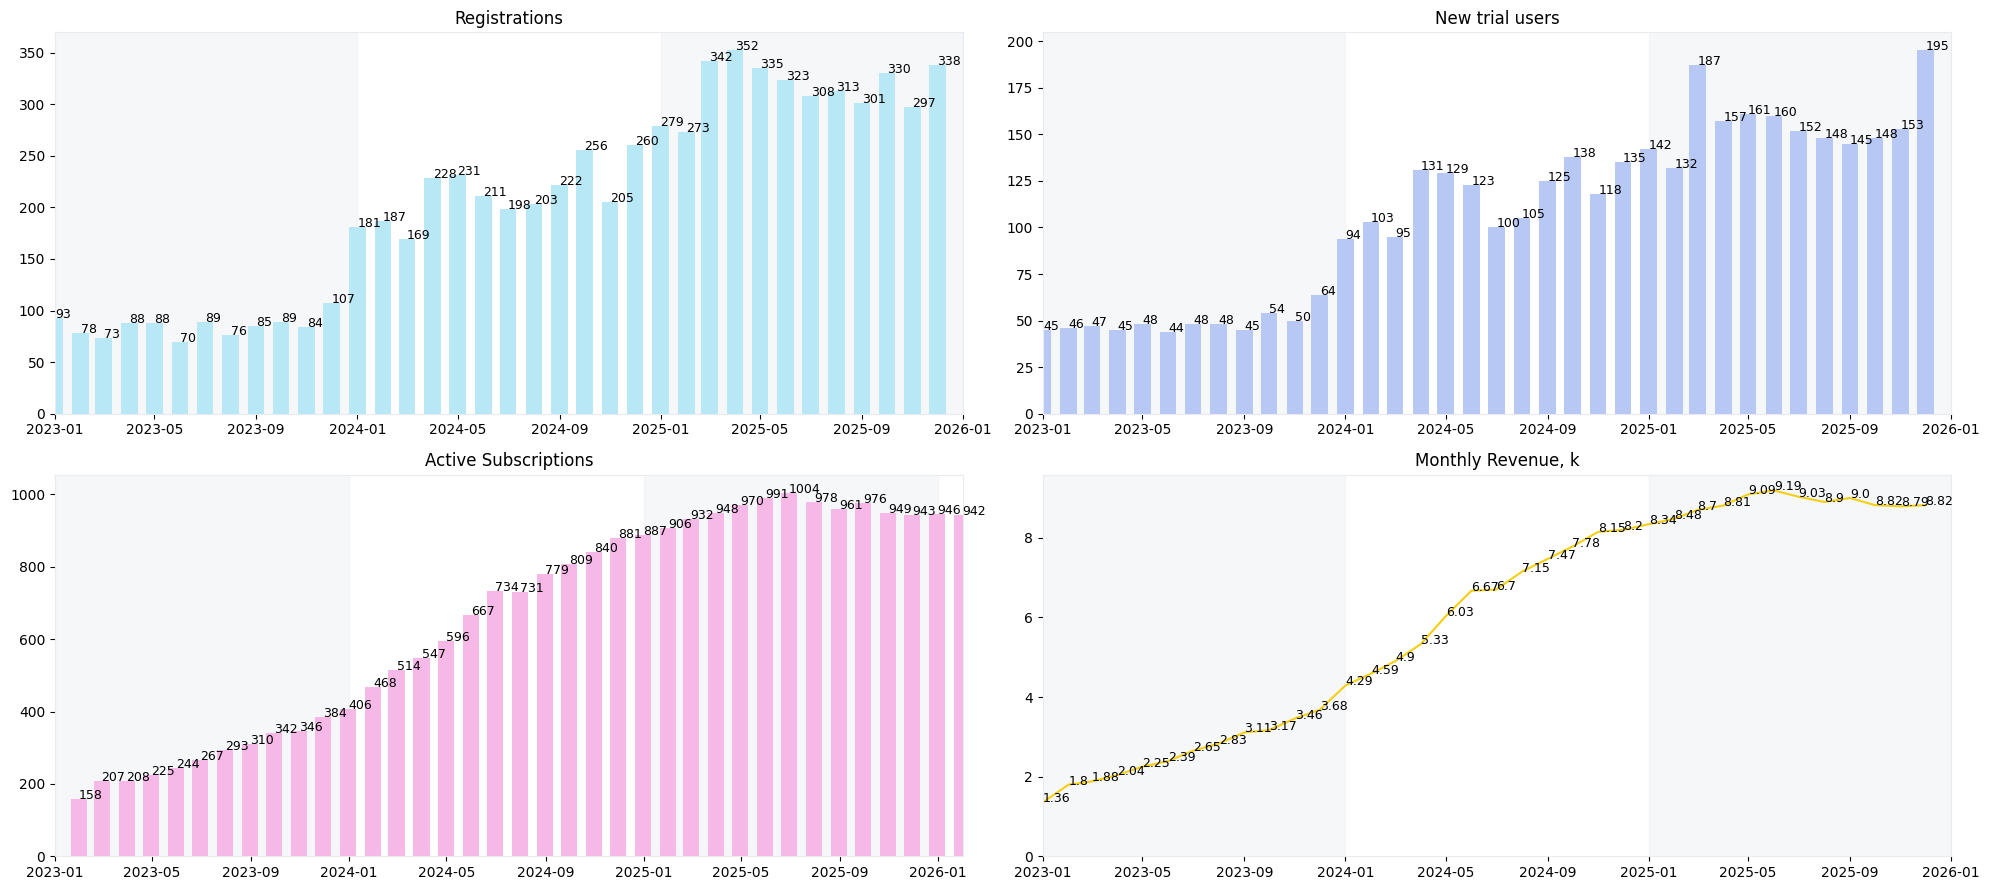

In [ ]:
# ------------------------------------------------------------------------------
# trends visualizations:
# - Registrations
# - Trials
# - Revenue
# - Active Subscriptions
# ------------------------------------------------------------------------------

# the period is cut as 2022's volume is low
min_period = np.datetime64('2023-01-01')

fig, ax = plt.subplots(2, 2, figsize = (20, 9))

# Registrations
line_chart_formatting (new_registrations[new_registrations['registration_month'] >= min_period],
                           'registration_month',
                           'new_users',
                           chart_type = 'bar',
                           title = 'Registrations',
                           main_color = '#B8E7F5',
                           span = True,
                           span_period = 'Year',
                           span_color = '#EAEBF0',
                           data_labels = True,
                           label = None,
                           min_y = 0,
                           ax = ax[0, 0]
                           )

# Trials
line_chart_formatting (monthly_trials[monthly_trials['trial_start_month'] >= min_period],
                           'trial_start_month',
                           'trial_users',
                           chart_type = 'bar',
                           title = 'New trial users',
                           main_color = '#B8C8F5',
                           span = True,
                           span_period = 'Year',
                           span_color = '#EAEBF0',
                           data_labels = True,
                           label = None,
                           min_y = 0,
                           ax = ax[0, 1]
                           )
# Active Subscriptions
line_chart_formatting (subscription_stats[subscription_stats['Dates'] >= min_period],
                           'Dates',
                           'active_subscriptions',
                           chart_type = 'bar',
                           title = 'Active Subscriptions',
                           main_color = '#F5B8E7',
                           span = True,
                           span_period = 'Year',
                           span_color = '#EAEBF0',
                           data_labels = True,
                           label = None,
                           min_y = 0,
                           ax = ax[1, 0]
                           )

# Revenue
line_chart_formatting (monthly_payments[monthly_payments['payment_month'] >= min_period],
                           'payment_month',
                           'amount_paid',
                           chart_type = 'line',
                           title = 'Monthly Revenue, k',
                           main_color = '#F5CF11',
                           span = True,
                           span_period = 'Year',
                           span_color = '#EAEBF0',
                           data_labels = True,
                           label = None,
                           ax = ax[1, 1]
                           )

plt.tight_layout()
plt.show()


####**Intermediate takeaway**

Registrations increased from **2,551 in 2024** to **3,791 in 2025** **(+48.6%)**, while trial users increased from **1,396 in 2024** to **1,880 in 2025 (+34.7%)**.
However, Active Subscriptions and Revenue flattened and then declined during 2025, indicating that the Registrations and Trials were not converting into paid users.

➔ **top-of-funnel volume is not the issue**

Next, other possible reasons should be checked:
- declining **Registration-to-Paid Conversion**
- rising **Subscriptions Churn**
- both

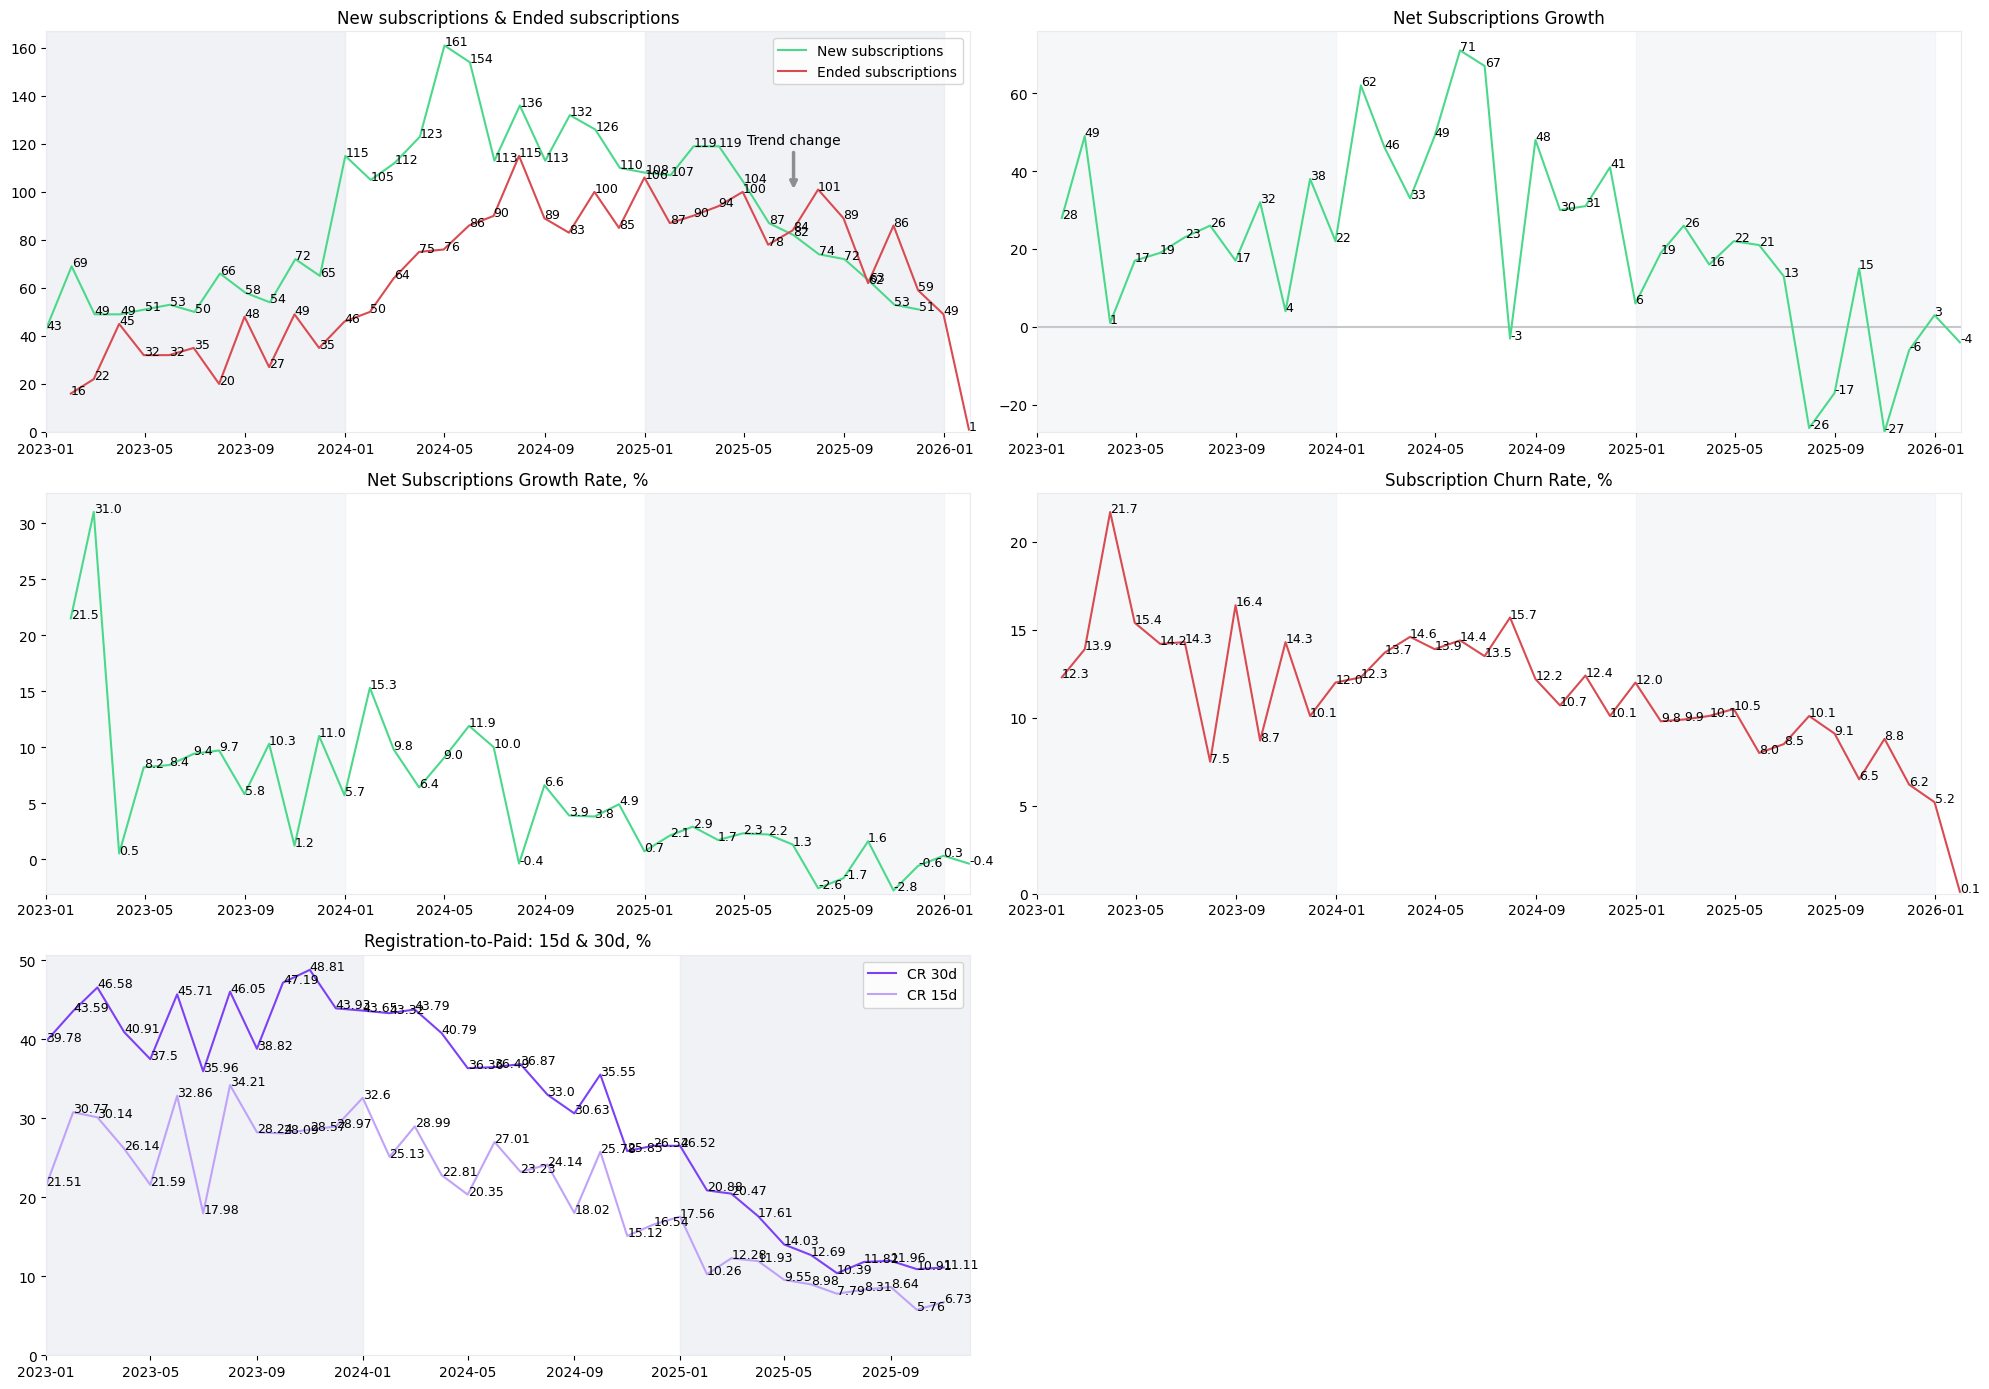

In [ ]:
# ------------------------------------------------------------------------------
# trends visualizations:
# - New and Ended Subscriptions
# - Net Subscriptions Growth
# - Net Subscriptions Growth Rate
# - Registration-to-Paid Conversion: 15d & 30d
# ------------------------------------------------------------------------------

fig, ax = plt.subplots(3, 2, figsize = (20, 14))

line_chart_formatting (monthly_new_subscriptions[monthly_new_subscriptions['subscription_month'] >= min_period],
                           'subscription_month',
                           'new_subscriptions',
                           chart_type = 'line',
                           title = 'New subscriptions & Ended subscriptions',
                           main_color = '#4AD98A',
                           span = True,
                           span_period = 'Year',
                           span_color = '#EAEBF0',
                           data_labels = True,
                           label = 'New subscriptions',
                           min_y = 0,
                           ax = ax[0, 0]
                           )

line_chart_formatting (subscription_stats[subscription_stats['Dates'] >= min_period],
                           'Dates',
                           'ended_subscriptions',
                           chart_type = 'line',
                           title = 'New subscriptions & Ended subscriptions',
                           main_color = '#D94A51',
                           span = True,
                           span_period = 'Year',
                           span_color = '#EAEBF0',
                           data_labels = True,
                           label = 'Ended subscriptions',
                           min_y = 0,
                           ax = ax[0, 0]
                           )
ax[0, 0].legend(loc = 'upper right')

ax[0, 0].annotate(
    'Trend change',
    xy = (np.datetime64('2025-07-01'), 100),
    xytext = (np.datetime64('2025-07-01'), 100 + 20),
    arrowprops = {'arrowstyle': '->', 'lw': 2.5, 'color' : '#8E8E8E'},
    ha = 'center'
)

line_chart_formatting (subscription_stats[subscription_stats['Dates'] >= min_period],
                           'Dates',
                           'net_subscriptions_growth',
                           chart_type = 'line',
                           title = 'Net Subscriptions Growth',
                           main_color = '#4AD98A',
                           span = True,
                           span_period = 'Year',
                           span_color = '#EAEBF0',
                           data_labels = True,
                           label = None,
                           min_y = int(min(subscription_stats['net_subscriptions_growth'])),
                           ax = ax[0, 1]
                           )
ax[0, 1].axhline(0, color = '#C7C7CB', zorder = 0)

line_chart_formatting (subscription_stats[subscription_stats['Dates'] >= min_period],
                           'Dates',
                           'net_growth_rate',
                           chart_type = 'line',
                           title = 'Net Subscriptions Growth Rate, %',
                           main_color = '#4AD98A',
                           span = True,
                           span_period = 'Year',
                           span_color = '#EAEBF0',
                           data_labels = True,
                           label = None,
                           min_y = subscription_stats['net_growth_rate'].min() - abs(subscription_stats['net_growth_rate'].min())* 0.1,
                           ax = ax[1, 0]
                           )

line_chart_formatting (subscription_stats[subscription_stats['Dates'] >= min_period],
                           'Dates',
                           'subscription_churn_rate',
                           chart_type = 'line',
                           title = 'Subscription Churn Rate, %',
                           main_color = '#D94A51',
                           span = True,
                           span_period = 'Year',
                           span_color = '#EAEBF0',
                           data_labels = True,
                           label = None,
                           min_y = 0,
                           ax = ax[1, 1]
                           )

line_chart_formatting (conversions_table_monthly[conversions_table_monthly['registration_month'] >= min_period],
                           'registration_month',
                           'CR_30_day',
                           chart_type = 'line',
                           title = 'Registration-to-Paid: 15d & 30d, %',
                           main_color = '#7D40F7',
                           span = True,
                           span_period = 'Year',
                           span_color = '#EAEBF0',
                           data_labels = True,
                           label = 'CR 30d',
                           min_y = 0,
                           ax = ax[2, 0]
                           )

line_chart_formatting (conversions_table_monthly[conversions_table_monthly['registration_month'] >= min_period],
                           'registration_month',
                           'CR_15_day',
                           chart_type = 'line',
                           title = 'Registration-to-Paid: 15d & 30d, %',
                           main_color = '#C0A2FB',
                           span = True,
                           span_period = 'Year',
                           span_color = '#EAEBF0',
                           data_labels = True,
                           label = 'CR 15d',
                           min_y = 0,
                           ax = ax[2, 0]
                           )

ax[2, 0].legend(loc = 'upper right')

ax[2, 1].remove()

plt.tight_layout()
plt.show()


## **Final block takeaway**

**Registrations** and **Trials** have an upward trend, but **Active Subscriptions** and subsequently **Revenue** are declining mid-2025

**Registration-to-Paid conversion** declines across mature cohorts in all windows. As a result, new subscription inflow weakens from mid-2024 onward.

The **Churn rate is declining**, suggesting that retention is not worsening. However, as **New subscriptions** inflow weakens, **Ended subscriptions** exceed **New subscriptions** in four of the six months from July to December 2025

➔  **The main driver for the decline in Active Subscriptions and Revenue seems to be falling Registration-to-Paid conversion, which reduces new paid subscription inflow**

The next block will research the reasons behind it